# Solving inverse problems with a Multivariate Field of Experts (MFoE)

This notebook shows how to use a trained MFoE regularizer to solve a linear inverse problem

$$\hat{\mathbf x} = \arg\min_{\mathbf x}\ \tfrac{1}{2}\|\mathbf{H x} - \mathbf y\|^2 + \lambda\, R_\sigma(\mathbf x).$$

A single `model(y, sigma, H=..., Ht=..., data_lip=..., x_init=...)` call runs the fixed-point solver internally and returns the reconstruction. We use image **inpainting** as a running example, but the same call works for any forward operator `H`.

In [1]:
import math
import torch
from models.mfoe import MFoE
import matplotlib.pyplot as plt
from torchmetrics.functional import peak_signal_noise_ratio as psnr

torch.set_grad_enabled(False)   # inference only: we never backprop through the solver
torch.manual_seed(0)            # reproducible mask and measurement noise
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Loading the model

We load the trained MFoE and move it to the device. The fixed-point solver sets its step size from the regularizer's Lipschitz constant, which depends on the spectral norm of the convolutional layer; `model(...)` refreshes that norm automatically at the start of every call, so there is nothing to do here beyond loading the weights.

In [2]:
infos = torch.load('trained_models/MFoE_groupsize_4/checkpoints/checkpoint_5000.pth', map_location='cpu', weights_only=True)
config = infos['config']
model = MFoE(param_model=config['model_params'], param_multi_conv=config['multi_convolution'],
             param_fw=config['optimization']['fixed_point_solver_fw_params'],
             param_bw=config['optimization']['fixed_point_solver_bw_params'])
model.load_state_dict(infos['state_dict'])
model.to(device)

Multi convolutionnal layer:  {'num_channels': [1, 4, 8, 60], 'size_kernels': [3, 5, 5]}


MFoE(
  (conv_layer): MultiConv2d(
    (conv_layers): ModuleList(
      (0): ParametrizedConv2d(
        1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): ZeroMean()
          )
        )
      )
      (1): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
      (2): Conv2d(8, 60, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    )
  )
  (mu): Sequential(
    (0): Linear(in_features=1, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): ReLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
  )
)

### Defining the Physics

We use a simple **inpainting** problem: the forward operator $\mathbf H$ keeps a random subset of the pixels (here 25%) and drops the rest, and we add a little Gaussian noise to the measurement. Because $\mathbf H$ is a binary mask it is symmetric ($\mathbf H = \mathbf H^\top$) and idempotent, so $\mathbf H^\top \mathbf H = \mathbf H$ is a projection and its Lipschitz constant `data_lip` is exactly $1$. For a different problem (deblurring, MRI, CT, ...) only `H`, `Ht` and `data_lip` change — the `model(...)` call stays the same.

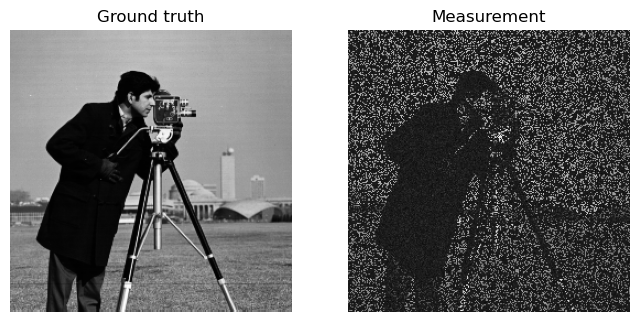

In [3]:
# load the ground truth image
img = torch.load('img.pt', map_location=device, weights_only=True)

# Inpainting forward model: keep 25% of the pixels at random, drop the rest.
mask = torch.bernoulli(torch.ones_like(img) * 0.25).to(device)
H = lambda x: mask * x
Ht = lambda x: mask * x                    # the mask is symmetric, so H == Ht
y = H(img) + 0.025 * torch.randn_like(img)  # noisy measurement
x_init = Ht(y)                             # initialization for the fixed point solver
data_lip = 1.0                             # ||H^T H|| = 1 since the mask is a projection

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img.cpu().numpy().squeeze(), cmap='gray')
ax[0].set_title('Ground truth')
ax[0].axis('off')
ax[1].imshow(y.cpu().numpy().squeeze(), cmap='gray')
ax[1].set_title('Measurement')
ax[1].axis('off');

### Testing hyperparameters

We sweep the regularization strength $\lambda$ and the denoiser noise level $\sigma$ in the objective

$$\hat{\mathbf x} = \arg\min_{\mathbf x}\ \tfrac{1}{2}\|\mathbf{H x} - \mathbf y\|^2 + \lambda\, R_\sigma(\mathbf x),$$

where $R_\sigma$ is the MFoE regularizer trained to denoise images corrupted by Gaussian noise of **standard deviation** $\sigma$ (the model was trained for $\sigma \in [0, 0.2]$).

**On the `lamb` parametrization.** The model keeps the regularization weight in *log-space*: the penalty is scaled by $\exp(\texttt{model.lamb})$, and `model.lamb` already holds the value learned during training. We treat the loop variable `lamb` as a multiplier *relative to that trained value* — scaling the weight by `lamb` means **adding** $\log(\texttt{lamb})$ to `model.lamb`. So `lamb = 1` reproduces the trained strength, `lamb < 1` regularizes less, and `lamb > 1` more.

/home/ducotter/miniforge3/envs/pytorch/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `peak_signal_noise_ratio` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `peak_signal_noise_ratio` from `torchmetrics.image` instead.
  _future_warning(


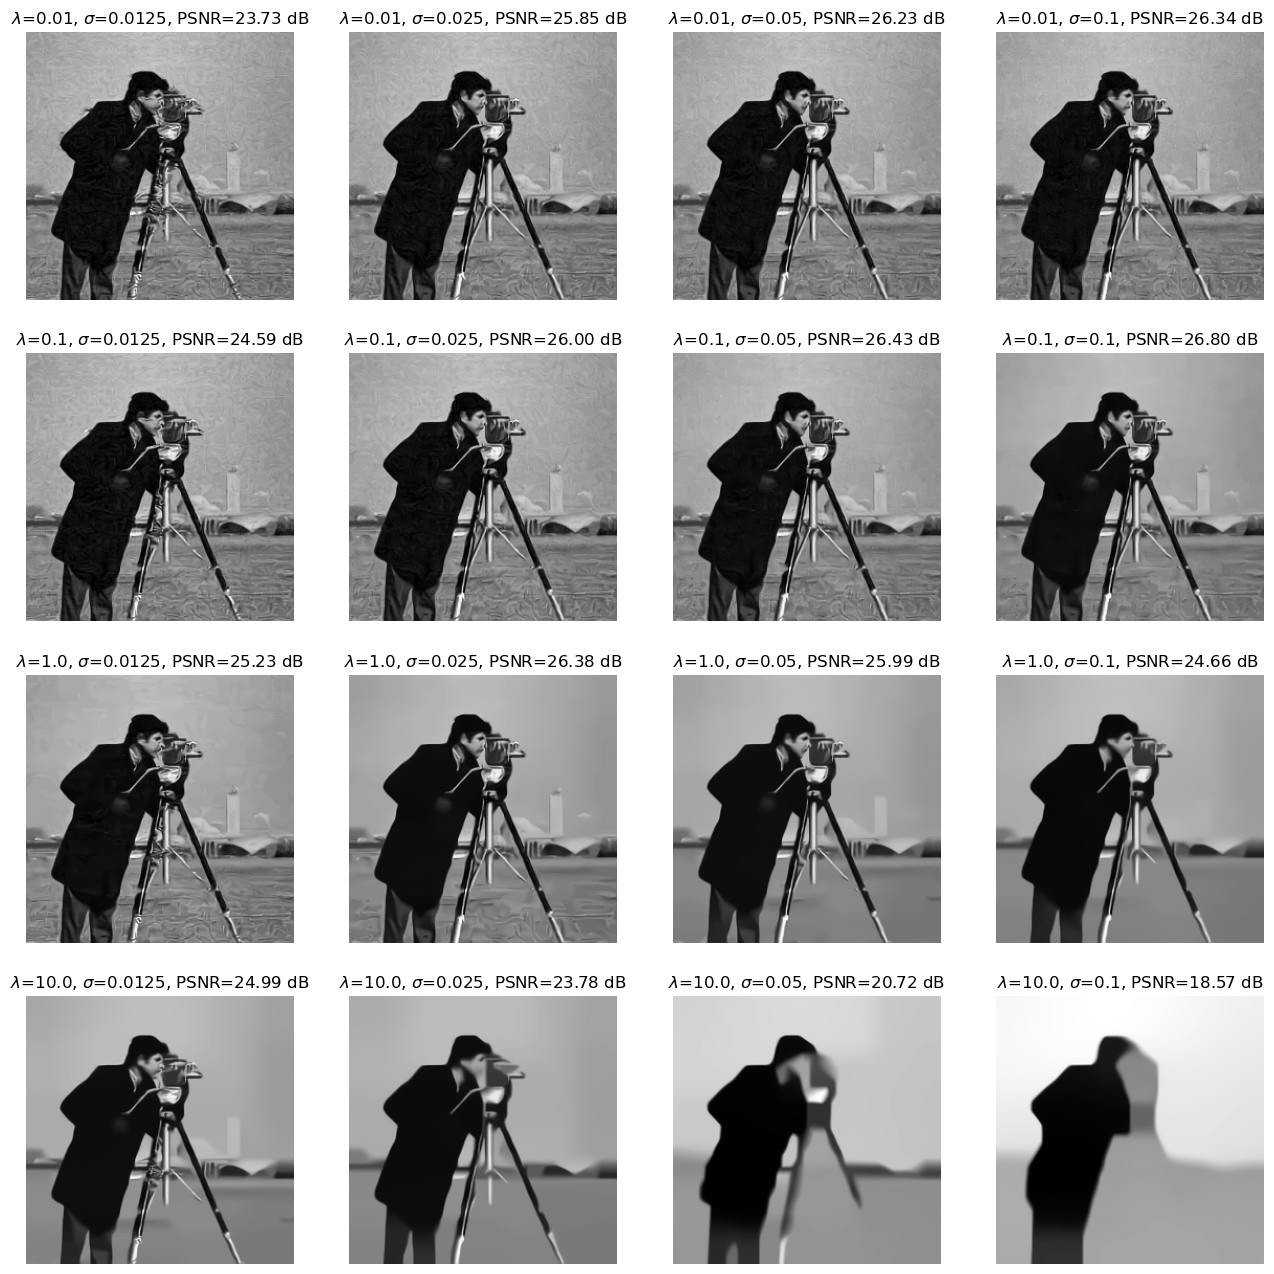

In [4]:
# create figure to show results
fig, ax = plt.subplots(4, 4, figsize=(16, 16))

# solver settings used at inference (forward() reads them from model.param_fw)
model.param_fw = {'max_iter': 1000, 'tol': 1e-5}

# trained (log-space) regularization strength; the sweep is defined relative to it
base_lamb = model.lamb.data.clone()

# coarse grid search over the regularization strength lambda and the denoiser noise level sigma
for i, lamb in enumerate([1e-2, 1e-1, 1.0, 10.0]):
    for j, sigma in enumerate([0.0125, 0.025, 0.05, 0.1]):  # model trained for sigma in [0, 0.2]

        # weight = exp(base_lamb) * lamb, i.e. base_lamb + log(lamb) in log-space
        model.lamb.data = base_lamb + math.log(lamb)

        x = model(y, sigma * torch.ones(1, 1, 1, 1, device=device),
                  H=H, Ht=Ht, data_lip=data_lip, x_init=x_init)

        score = psnr(x.clip(0, 1), img, data_range=1.0).item()
        ax[i, j].imshow(x.cpu().squeeze().clip(0, 1), cmap='gray')
        ax[i, j].set_title(f"$\\lambda$={lamb}, $\\sigma$={sigma}, PSNR={score:.2f} dB")
        ax[i, j].axis('off')

# restore the trained value so the model is left in a clean state
model.lamb.data = base_lamb

### A note on hyperparameter selection

The grid above is a **very basic** search: a few $(\lambda, \sigma)$ values scored on a *single* image, and against its ground truth — which you would not have access to in practice. It is only meant to build intuition.

For real use, prefer [`inverse_problems/tune_hyperparameters.py`](inverse_problems/tune_hyperparameters.py), which runs a zeroth-order (pattern) search over $(\lambda, \sigma)$ and evaluates each candidate on a **validation dataset**. It is considerably more reliable than this hand-picked grid — and slower, since every candidate reconstructs the whole validation set. See `inverse_problems/deblurring/blur_reconstruction.py` for an end-to-end example of how it is called.